## 최종 결과 시각화 (Thread × Bandwidth)

아래 셀은 최종 실험에서 생성된 `search_*.csv`를 읽어 **thread, bandwidth 별 성능/병목 지표**를 시각화합니다.

- 그룹 막대그래프: `QPS`, `Latency`, `Disk stall`, `CPU idle`
- **총 시간 vs idle 시간 비교**: `mean_io_us` vs `mean_disk_idle_us`, `mean_cpu_us` vs `mean_cpu_idle_us`
- **비율 시각화**: `disk_idle_ratio = mean_disk_idle_us / mean_io_us`, `cpu_idle_ratio = mean_cpu_idle_us / mean_cpu_us`
- 히트맵: `QPS`, `Latency`, `Disk/CPU idle ratio`

,bandwidth,threads,qps,mean_latency_us,mean_io_us,mean_disk_idle_us,mean_cpu_us,mean_cpu_idle_us,disk_idle_ratio,cpu_idle_ratio
0,1,1,143.380,6741.46,6183.16,4129.210,6593.77,4129.210,0.667815,0.626229
1,1,2,303.578,6381.13,5870.02,3994.290,6239.55,3994.290,0.680456,0.640157
2,1,4,629.564,6163.42,5674.06,3892.820,6025.27,3892.820,0.686073,0.646082
3,1,8,1265.280,6163.11,5729.28,4161.570,6033.81,4161.570,0.726369,0.689708
4,1,16,2316.100,6791.85,6430.19,5215.810,6680.01,5215.810,0.811144,0.780809
5,2,1,224.055,4314.40,3935.30,2598.750,4224.97,2598.750,0.660369,0.615093
6,2,2,457.536,4232.47,3873.66,2610.450,4145.99,2610.450,0.673898,0.629632
7,2,4,899.453,4311.93,3952.38,2689.360,4225.76,2689.360,0.680441,0.636420
8,2,8,1668.550,4668.23,4319.16,3086.250,4584.66,3086.250,0.714549,0.673169
9,2,16,2713.670,5774.07,5394.01,4092.750,5695.25,4092.750,0.758758,0.718625


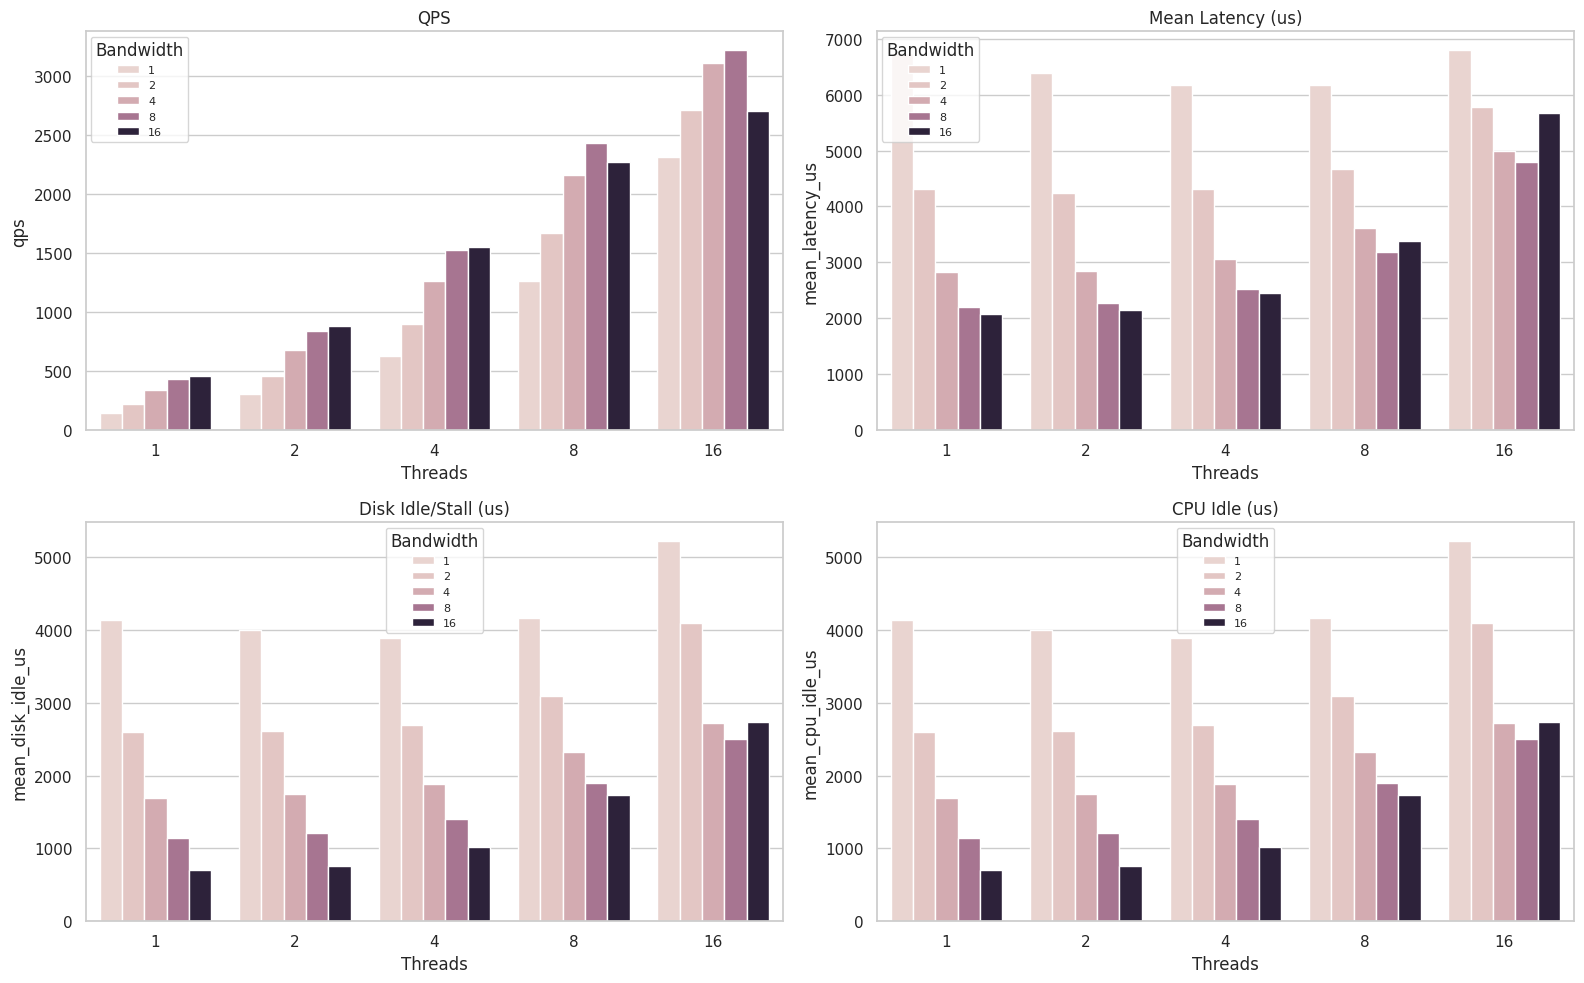

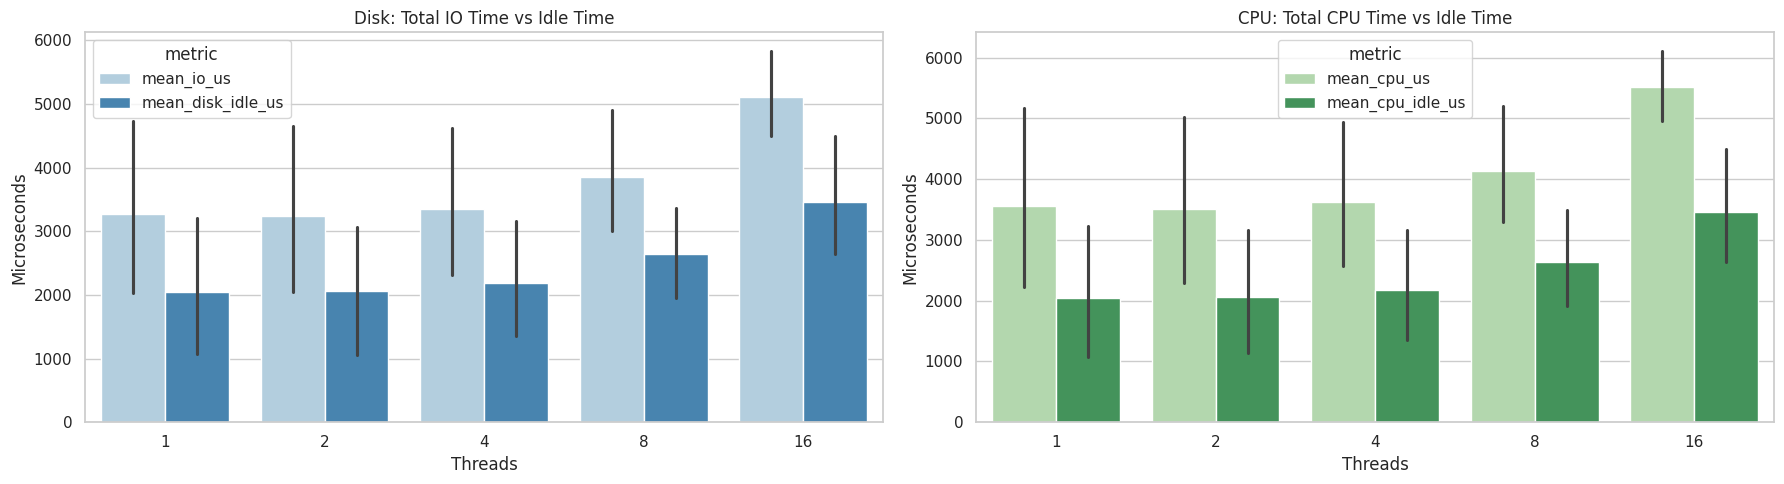

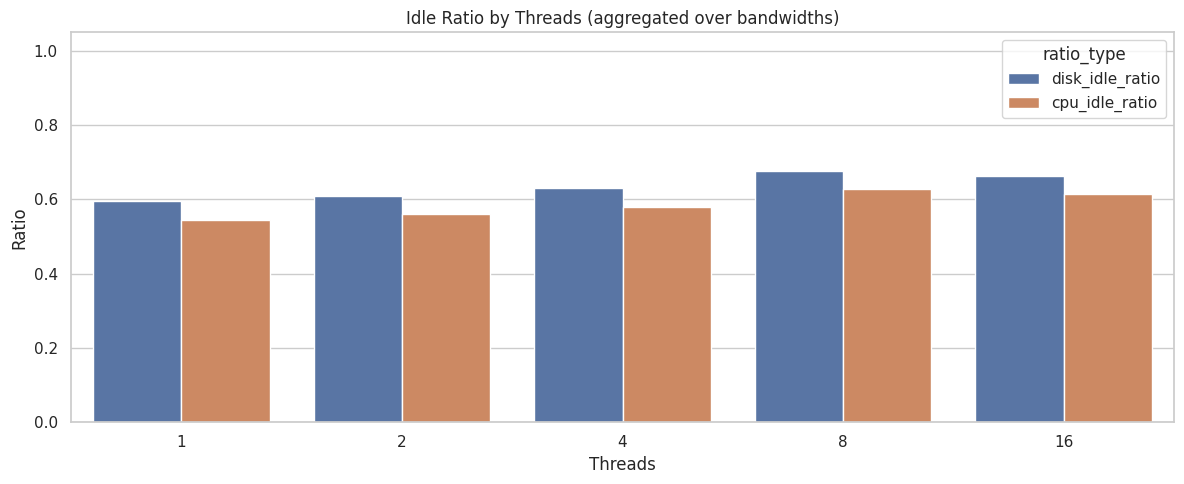

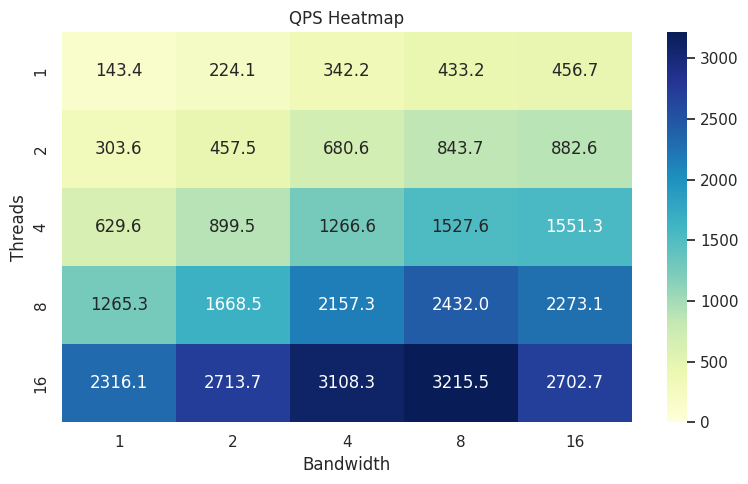

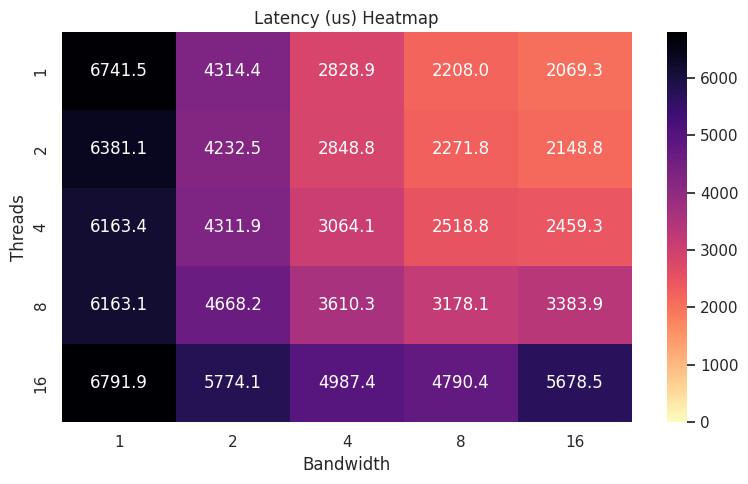

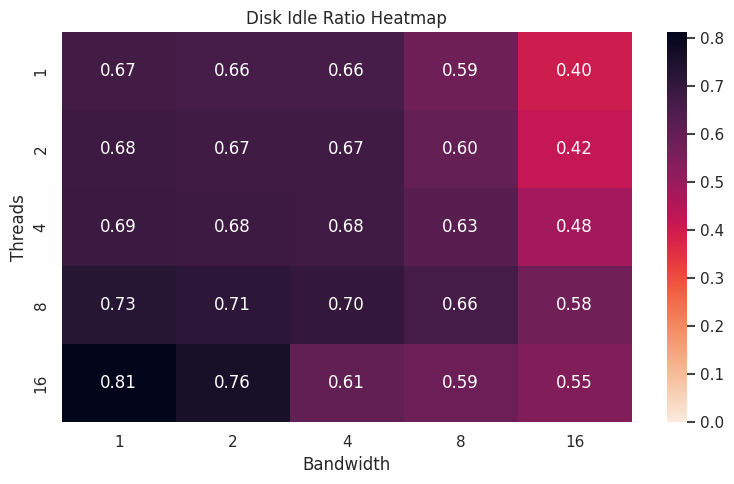

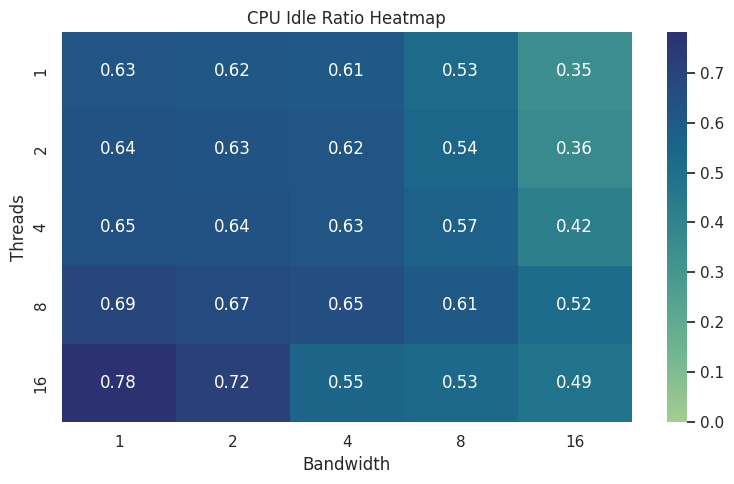

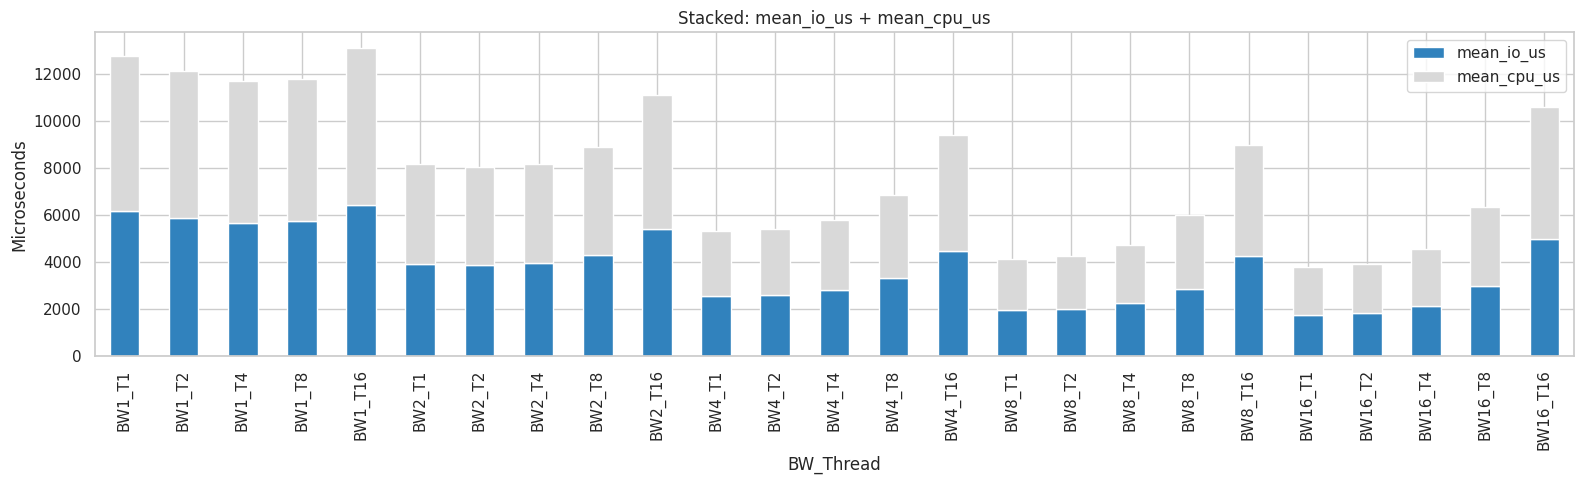

Saved: /home/yeojinoh/workspace/nvme_data/starling/sift/index/sift_base_M32_R32_L50_B1.2/search/analysis_thread_bandwidth_metrics.csv


In [16]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

search_dir = Path('/home/yeojinoh/workspace/nvme_data/starling/sift/index/sift_base_M32_R32_L50_B1.2/search')
csv_files = sorted(search_dir.glob('search_*.csv'))

if not csv_files:
    raise FileNotFoundError(f'No search csv files found in: {search_dir}')

rows = []
for file_path in csv_files:
    m_bw = re.search(r'BW(\d+)', file_path.name)
    m_t = re.search(r'_T(\d+)', file_path.name)
    bw = int(m_bw.group(1)) if m_bw else np.nan
    th = int(m_t.group(1)) if m_t else np.nan

    tmp = pd.read_csv(file_path)
    if tmp.empty:
        continue

    tmp['bandwidth'] = bw
    tmp['threads'] = th
    tmp['file'] = file_path.name
    rows.append(tmp)

exp_df = pd.concat(rows, ignore_index=True)
exp_df = exp_df.sort_values(['bandwidth', 'threads']).reset_index(drop=True)

# 파생 비율 지표
exp_df['disk_idle_ratio'] = np.where(exp_df['mean_io_us'] > 0,
                                     exp_df['mean_disk_idle_us'] / exp_df['mean_io_us'],
                                     np.nan)
exp_df['cpu_idle_ratio'] = np.where(exp_df['mean_cpu_us'] > 0,
                                    exp_df['mean_cpu_idle_us'] / exp_df['mean_cpu_us'],
                                    np.nan)
exp_df['bw_t'] = exp_df.apply(lambda x: f"BW{int(x['bandwidth'])}_T{int(x['threads'])}", axis=1)

display(exp_df[['bandwidth', 'threads', 'qps', 'mean_latency_us', 'mean_io_us',
                'mean_disk_idle_us', 'mean_cpu_us', 'mean_cpu_idle_us',
                'disk_idle_ratio', 'cpu_idle_ratio']].head(30))

# 1) 핵심 성능/지연 지표 막대그래프
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
metrics = [
    ('qps', 'QPS'),
    ('mean_latency_us', 'Mean Latency (us)'),
    ('mean_disk_idle_us', 'Disk Idle/Stall (us)'),
    ('mean_cpu_idle_us', 'CPU Idle (us)')
]

for ax, (metric, title) in zip(axes.ravel(), metrics):
    sns.barplot(data=exp_df, x='threads', y=metric, hue='bandwidth', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Threads')
    ax.legend(title='Bandwidth', fontsize=8)

plt.tight_layout()
plt.show()

# 2) 총 시간 vs idle 시간 비교 (Disk / CPU)
compare_disk = exp_df[['bandwidth', 'threads', 'mean_io_us', 'mean_disk_idle_us']].melt(
    id_vars=['bandwidth', 'threads'],
    value_vars=['mean_io_us', 'mean_disk_idle_us'],
    var_name='metric',
    value_name='us'
)

compare_cpu = exp_df[['bandwidth', 'threads', 'mean_cpu_us', 'mean_cpu_idle_us']].melt(
    id_vars=['bandwidth', 'threads'],
    value_vars=['mean_cpu_us', 'mean_cpu_idle_us'],
    var_name='metric',
    value_name='us'
)

fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharey=False)
sns.barplot(data=compare_disk, x='threads', y='us', hue='metric', ax=axes[0], palette='Blues')
axes[0].set_title('Disk: Total IO Time vs Idle Time')
axes[0].set_xlabel('Threads')
axes[0].set_ylabel('Microseconds')

sns.barplot(data=compare_cpu, x='threads', y='us', hue='metric', ax=axes[1], palette='Greens')
axes[1].set_title('CPU: Total CPU Time vs Idle Time')
axes[1].set_xlabel('Threads')
axes[1].set_ylabel('Microseconds')

plt.tight_layout()
plt.show()

# 3) 비율 시각화 (막대 + 히트맵)
ratio_long = exp_df[['bandwidth', 'threads', 'disk_idle_ratio', 'cpu_idle_ratio']].melt(
    id_vars=['bandwidth', 'threads'],
    value_vars=['disk_idle_ratio', 'cpu_idle_ratio'],
    var_name='ratio_type',
    value_name='ratio'
)

plt.figure(figsize=(12, 5))
sns.barplot(data=ratio_long, x='threads', y='ratio', hue='ratio_type', errorbar=None)
plt.title('Idle Ratio by Threads (aggregated over bandwidths)')
plt.xlabel('Threads')
plt.ylabel('Ratio')
plt.ylim(0, max(1.05, np.nanmax(ratio_long['ratio']) * 1.1))
plt.tight_layout()
plt.show()

# thread x bandwidth 히트맵

def make_heatmap(metric_col, title, fmt='.2f', cmap='YlGnBu'):
    pivot = exp_df.pivot_table(index='threads', columns='bandwidth', values=metric_col, aggfunc='mean')
    plt.figure(figsize=(8, 5))
    sns.heatmap(pivot, annot=True, fmt=fmt, cmap=cmap, vmin=0)
    plt.title(title)
    plt.xlabel('Bandwidth')
    plt.ylabel('Threads')
    plt.tight_layout()
    plt.show()

make_heatmap('qps', 'QPS Heatmap', fmt='.1f')
make_heatmap('mean_latency_us', 'Latency (us) Heatmap', fmt='.1f', cmap='magma_r')
make_heatmap('disk_idle_ratio', 'Disk Idle Ratio Heatmap', fmt='.2f', cmap='rocket_r')
make_heatmap('cpu_idle_ratio', 'CPU Idle Ratio Heatmap', fmt='.2f', cmap='crest')

# 4) 스택 막대그래프 (총 Disk IO + 총 CPU)
stack_df = exp_df[['bw_t', 'mean_io_us', 'mean_cpu_us']].set_index('bw_t')
stack_df.plot(kind='bar', stacked=True, figsize=(16, 5), colormap='tab20c')
plt.title('Stacked: mean_io_us + mean_cpu_us')
plt.xlabel('BW_Thread')
plt.ylabel('Microseconds')
plt.tight_layout()
plt.show()

# 결과 저장
exp_df.to_csv(search_dir / 'analysis_thread_bandwidth_metrics.csv', index=False)
print(f"Saved: {search_dir / 'analysis_thread_bandwidth_metrics.csv'}")